In [1]:
import os

broken_path = "/cluster/tufts/apps/manual/9/x86_64/jupyter/4.5.0/bin"

if broken_path in os.environ.get("PATH", ""):
    os.environ["PATH"] = os.environ["PATH"].replace(broken_path + ":", "").replace(broken_path, "")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
import copy
import random
import numpy as np
import pandas as pd
import torch


In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import approximate_posteriors
import layers
import utils


In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


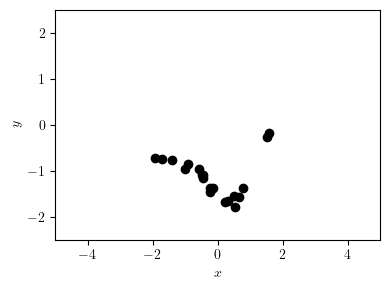

In [5]:
N = 20
D = 1
X_numpy = np.random.randn(N, D)
K = utils.rbf_kernel(X_numpy, X_numpy, lengthscale=1.0, outputscale=1.0)
#K = utils.matern_kernel(X_numpy, X_numpy, lengthscale=1.0, nu=2.5, outputscale=1.0)
#y_numpy = np.sin(3 * np.sum(X_numpy, axis=1, keepdims=True)) + 0.1 * np.random.randn(N, 1)
y_numpy = np.random.multivariate_normal(mean=np.zeros(N), cov=K, size=1).reshape(N, 1) + 0.1 * np.random.randn(N, 1)

X = torch.tensor(X_numpy.reshape(-1, 1), dtype=torch.float64)
y = torch.tensor(y_numpy.reshape(-1, 1), dtype=torch.float64)

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows)

ax.scatter(X_numpy, y_numpy, color="#000000")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim([-5, 5])
ax.set_ylim([-2.5, 2.5])

fig.tight_layout()
plt.show()


In [6]:
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=0.1, outputscale=1.0, R=1_024)
init_state_dict = copy.deepcopy(phi.state_dict())


In [7]:
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=0.1, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
model = approximate_posteriors.FullRankCovariance(
    m = None,
    S = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
#elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
#elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
        
    Phi = phi(X)
    snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
    fullrank_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.sigma_n2)).item()
    fullrank_relative_snr = fullrank_snr / snr
    
    idx = np.argmax(elbos)
    fullrank_elbo = elbos[idx]
    fullrank_lml = lmls[idx]
    fullrank_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

    X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
    Phi_star = phi(X_star)
    fullrank_mean = model.sigma_f * Phi_star @ model.m
    fullrank_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
    fullrank_var_y = fullrank_var_f + model.sigma_n2


In [8]:
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=0.1, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
model = approximate_posteriors.DiagonalCovariance(
    m = None,
    s = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
#elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
#elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
    
    Phi = phi(X)
    snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
    diagonal_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.sigma_n2)).item()
    diagonal_relative_snr = diagonal_snr / snr
    
    idx = np.argmax(elbos)
    diagonal_elbo = elbos[idx]
    diagonal_lml = lmls[idx]
    diagonal_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

    X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
    Phi_star = phi(X_star)
    diagonal_mean = model.sigma_f * Phi_star @ model.m
    diagonal_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
    diagonal_var_y = diagonal_var_f + model.sigma_n2


In [9]:
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=0.1, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
k = 512
model = approximate_posteriors.LowRankPlusDiagonalCovariance(
    C = None,
    d_2 = None,
    k = torch.tensor(k, dtype=torch.int64),
    L = None,
    m = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
#elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
#elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
    
    phi.load_state_dict(best_checkpoint["phi"])
    model.load_state_dict(best_checkpoint["model"])
    
    Phi = phi(X)
    snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
    lowrank_plus_diagonal_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.sigma_n2)).item()
    lowrank_plus_diagonal_relative_snr = lowrank_plus_diagonal_snr / snr
    
    idx = np.argmax(elbos)
    lowrank_plus_diagonal_elbo = elbos[idx]
    lowrank_plus_diagonal_lml = lmls[idx]
    lowrank_plus_diagonal_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

    X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
    Phi_star = phi(X_star)
    lowrank_plus_diagonal_mean = model.sigma_f * Phi_star @ model.m
    lowrank_plus_diagonal_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
    lowrank_plus_diagonal_var_y = lowrank_plus_diagonal_var_f + model.sigma_n2


In [10]:
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
#phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi = layers.RBFRFFs(D=D, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=0.1, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
k = 512
model = approximate_posteriors.LowRankCovariance(
    C = None,
    d_2 = 1e-6 * torch.ones((1_024 - k,), dtype=torch.float64),
    k = torch.tensor(k, dtype=torch.int64),
    L = None,
    m = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
#elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
#elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
        
    Phi = phi(X)
    snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
    lowrank_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.sigma_n2)).item()
    lowrank_relative_snr = lowrank_snr / snr
    
    idx = np.argmax(elbos)
    lowrank_elbo = elbos[idx]
    lowrank_lml = lmls[idx]
    lowrank_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

    X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
    Phi_star = phi(X_star)
    lowrank_mean = model.sigma_f * Phi_star @ model.m
    lowrank_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
    lowrank_var_y = lowrank_var_f + model.sigma_n2


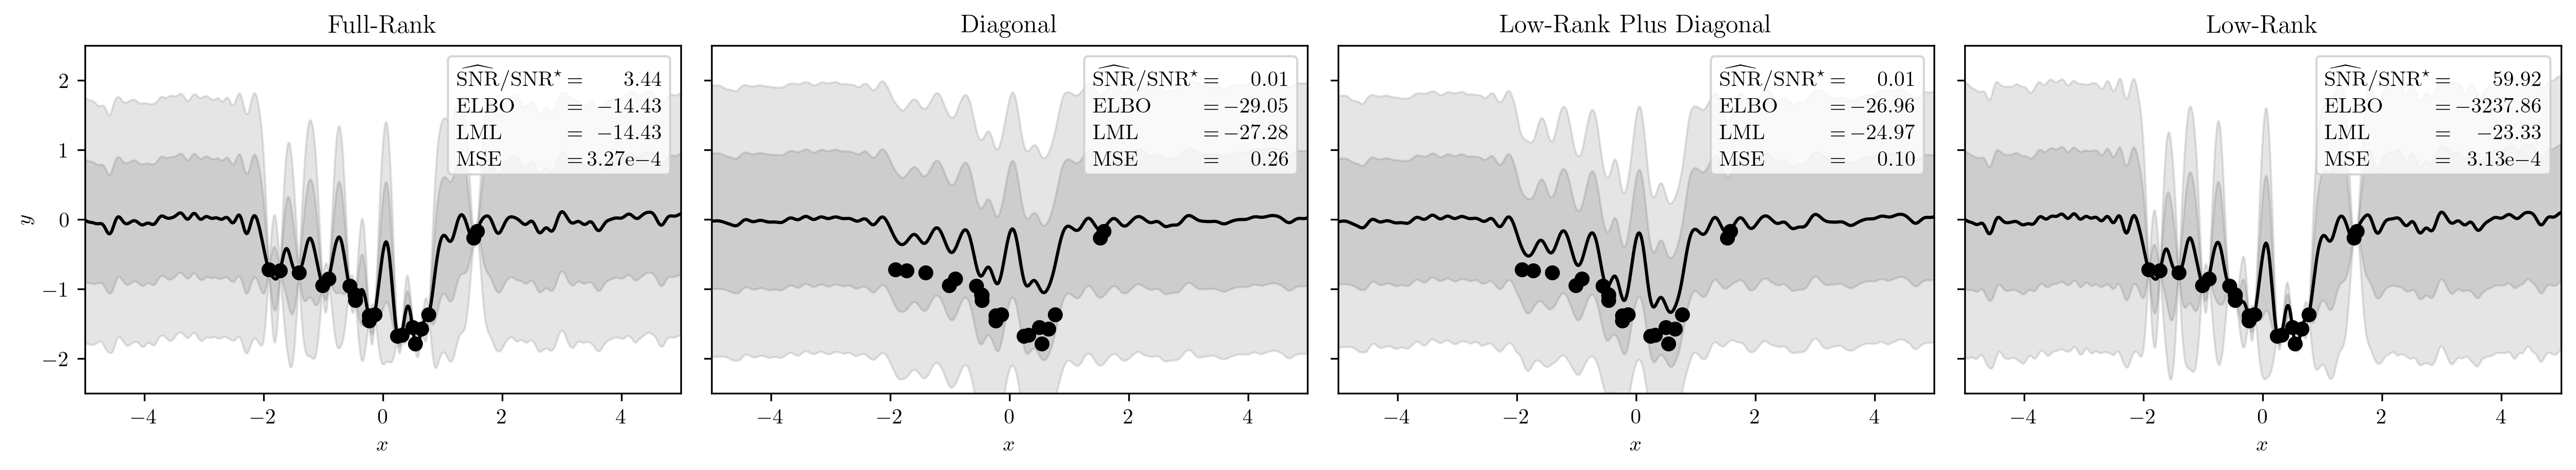

In [11]:
def format_number(x, precision=2):
    if abs(x) < 0.005:
        mantissa, exp = f"{x:.{precision}e}".split("e")
        exp = int(exp)
        return rf"\mathrm{{{mantissa}e{exp}}}".replace("-", "{-}")
    else:
        return rf"\mathrm{{{x:.{precision}f}}}"

linspace = np.linspace(start=-5, stop=5, num=1_000)

ncols, nrows = 4, 1
zoom = 2.5
latex_width_pts = 487.8225
inches_per_pt = 1.0 / 72.27
figure_width_inches = latex_width_pts * inches_per_pt
figure_height_inches = (3 / 4) * (nrows / ncols) * figure_width_inches

fig, axs = plt.subplots(dpi=300, figsize=(zoom * figure_width_inches, zoom * figure_height_inches), ncols=ncols, nrows=nrows, sharey="row")

axs[0].scatter(X_numpy, y_numpy, color="#000000")
axs[0].fill_between(linspace, fullrank_mean.squeeze() + 2 * torch.sqrt(fullrank_var_y).squeeze(), fullrank_mean.squeeze() - 2 * torch.sqrt(fullrank_var_y).squeeze(), alpha=0.1, color="#000000")
axs[0].fill_between(linspace, fullrank_mean.squeeze() + 1 * torch.sqrt(fullrank_var_y).squeeze(), fullrank_mean.squeeze() - 1 * torch.sqrt(fullrank_var_y).squeeze(), alpha=0.1, color="#000000")
axs[0].plot(linspace, fullrank_mean.squeeze(), color="#000000")
axs[0].plot([], [], " ", label=(
    r"$\begin{array}{l@{\,}c@{\,}r}"
    rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {fullrank_relative_snr:.2f} \\"
    rf"\mathrm{{ELBO}} &=& {format_number(fullrank_elbo)} \\"
    rf"\mathrm{{LML}} &=& {format_number(fullrank_lml)} \\"
    rf"\mathrm{{MSE}} &=& {format_number(fullrank_mse)} \\"
    r"\end{array}$"
))
axs[0].set_title("Full-Rank")
axs[0].set_xlabel(r"$x$")
axs[0].set_ylabel(r"$y$")
axs[0].set_xlim([-5, 5])
axs[0].set_ylim([-2.5, 2.5])
axs[0].legend(loc="upper right", handlelength=0, handletextpad=0)

axs[1].scatter(X_numpy, y_numpy, color="#000000")
axs[1].fill_between(linspace, diagonal_mean.squeeze() + 2 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 2 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
axs[1].fill_between(linspace, diagonal_mean.squeeze() + 1 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 1 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
axs[1].plot(linspace, diagonal_mean.squeeze(), color="#000000")
axs[1].plot([], [], " ", label=(
    r"$\begin{array}{l@{\,}c@{\,}r}"
    rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {diagonal_relative_snr:.2f} \\"
    rf"\mathrm{{ELBO}} &=& {format_number(diagonal_elbo)} \\"
    rf"\mathrm{{LML}} &=& {format_number(diagonal_lml)} \\"
    rf"\mathrm{{MSE}} &=& {format_number(diagonal_mse)} \\"
    r"\end{array}$"
))
axs[1].set_title("Diagonal")
axs[1].set_xlabel(r"$x$")
axs[1].set_xlim([-5, 5])
axs[1].set_ylim([-2.5, 2.5])
axs[1].legend(loc="upper right", handlelength=0, handletextpad=0)

axs[2].scatter(X_numpy, y_numpy, color="#000000")
axs[2].fill_between(linspace, lowrank_plus_diagonal_mean.squeeze() + 2 * torch.sqrt(lowrank_plus_diagonal_var_y).squeeze(), lowrank_plus_diagonal_mean.squeeze() - 2 * torch.sqrt(lowrank_plus_diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
axs[2].fill_between(linspace, lowrank_plus_diagonal_mean.squeeze() + 1 * torch.sqrt(lowrank_plus_diagonal_var_y).squeeze(), lowrank_plus_diagonal_mean.squeeze() - 1 * torch.sqrt(lowrank_plus_diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
axs[2].plot(linspace, lowrank_plus_diagonal_mean.squeeze(), color="#000000")
axs[2].plot([], [], " ", label=(
    r"$\begin{array}{l@{\,}c@{\,}r}"
    rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {lowrank_plus_diagonal_relative_snr:.2f} \\"
    rf"\mathrm{{ELBO}} &=& {format_number(lowrank_plus_diagonal_elbo)} \\"
    rf"\mathrm{{LML}} &=& {format_number(lowrank_plus_diagonal_lml)} \\"
    rf"\mathrm{{MSE}} &=& {format_number(lowrank_plus_diagonal_mse)} \\"
    r"\end{array}$"
))
axs[2].set_title("Low-Rank Plus Diagonal")
axs[2].set_xlabel(r"$x$")
axs[2].set_xlim([-5, 5])
axs[2].set_ylim([-2.5, 2.5])
axs[2].legend(loc="upper right", handlelength=0, handletextpad=0)

axs[3].scatter(X_numpy, y_numpy, color="#000000")
axs[3].fill_between(linspace, lowrank_mean.squeeze() + 2 * torch.sqrt(lowrank_var_y).squeeze(), lowrank_mean.squeeze() - 2 * torch.sqrt(lowrank_var_y).squeeze(), alpha=0.1, color="#000000")
axs[3].fill_between(linspace, lowrank_mean.squeeze() + 1 * torch.sqrt(lowrank_var_y).squeeze(), lowrank_mean.squeeze() - 1 * torch.sqrt(lowrank_var_y).squeeze(), alpha=0.1, color="#000000")
axs[3].plot(linspace, lowrank_mean.squeeze(), color="#000000")
axs[3].plot([], [], " ", label=(
    r"$\begin{array}{l@{\,}c@{\,}r}"
    rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {lowrank_relative_snr:.2f} \\"
    rf"\mathrm{{ELBO}} &=& {format_number(lowrank_elbo)} \\"
    rf"\mathrm{{LML}} &=& {format_number(lowrank_lml)} \\"
    rf"\mathrm{{MSE}} &=& {format_number(lowrank_mse)} \\"
    r"\end{array}$"
))
axs[3].set_title("Low-Rank")
axs[3].set_xlabel(r"$x$")
axs[3].set_xlim([-5, 5])
axs[3].set_ylim([-2.5, 2.5])
axs[3].legend(loc="upper right", handlelength=0, handletextpad=0)

fig.tight_layout()
fig.savefig("under_overestimating.pdf", bbox_inches="tight")
plt.show()